# Análisis Exploratorio de Datos (EDA): Prediciendo diabetes

## Planteamiento del problema y recopilación de datos

In [2]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import json
import numpy as np
from numpy._core.defchararray import upper

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import pickle
from sklearn.feature_selection import f_classif, SelectKBest


# Leer el archivo CSV
df = pd.read_csv('https://breathecode.herokuapp.com/asset/internal-link?id=930&path=diabetes.csv', sep=',') # Este archivo CSV contiene comas como separadores
print(df.head())
print(df.columns)

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')


## Exploración y limpieza de datos

Comprobamos las dimensiones del dataframe y, además de si los datos concuerdan con el número total, vemos el tipo de dato y podemos separar entre variables categóricas y numéricas

In [3]:
print(f"Dimensiones del dataframe: {df.shape}")
print(df.info())

Dimensiones del dataframe: (768, 9)
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


Procedemos a contabilizar los nulos y únicos: 

In [4]:
print(f"Valores null por columna: \n{df.isnull().sum()}")
print(f"Valores unicos por columna: \n{df.nunique()}")

Valores null por columna: 
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64
Valores unicos por columna: 
Pregnancies                  17
Glucose                     136
BloodPressure                47
SkinThickness                51
Insulin                     186
BMI                         248
DiabetesPedigreeFunction    517
Age                          52
Outcome                       2
dtype: int64


#### Resumen de cada columna:

Pregnancies. Número de embarazos del paciente (numérico)  
Glucose. Concentración de glucosa en plasma a las 2 horas de un test de tolerancia oral a la glucosa (numérico)  
BloodPressure. Presión arterial diastólica (medida en mm Hg) (numérico)  
SkinThickness. Grosor del pliegue cutáneo del tríceps (medida en mm) (numérico)  
Insulin. Insulina sérica de 2 horas (medida en mu U/ml) (numérico)  
BMI. Índice de masa corporal (numérico)  
DiabetesPedigreeFunction. Función de pedigrí de diabetes (numérico)  
Age. Edad del paciente (numérico)  
Outcome. Variable de clase (0 o 1), siendo 0 negativo en diabetes y 1, positivo (numérico)

### Eliminamos las columnas que no nos aportan datos relevantes

En este caso no hay posibles duplicados en datos que generen conflictos y todas las columnas aportan información vital, por lo cual continuaremos con el análisis.

In [5]:
total_dataf = df
print(total_dataf.columns)
total_dataf.head()

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Análisis de variables univariante

### Este dataset no tiene valores categóricos por lo que no se pueden generar gráficos

### Generamos gráficos con los valores numéricos

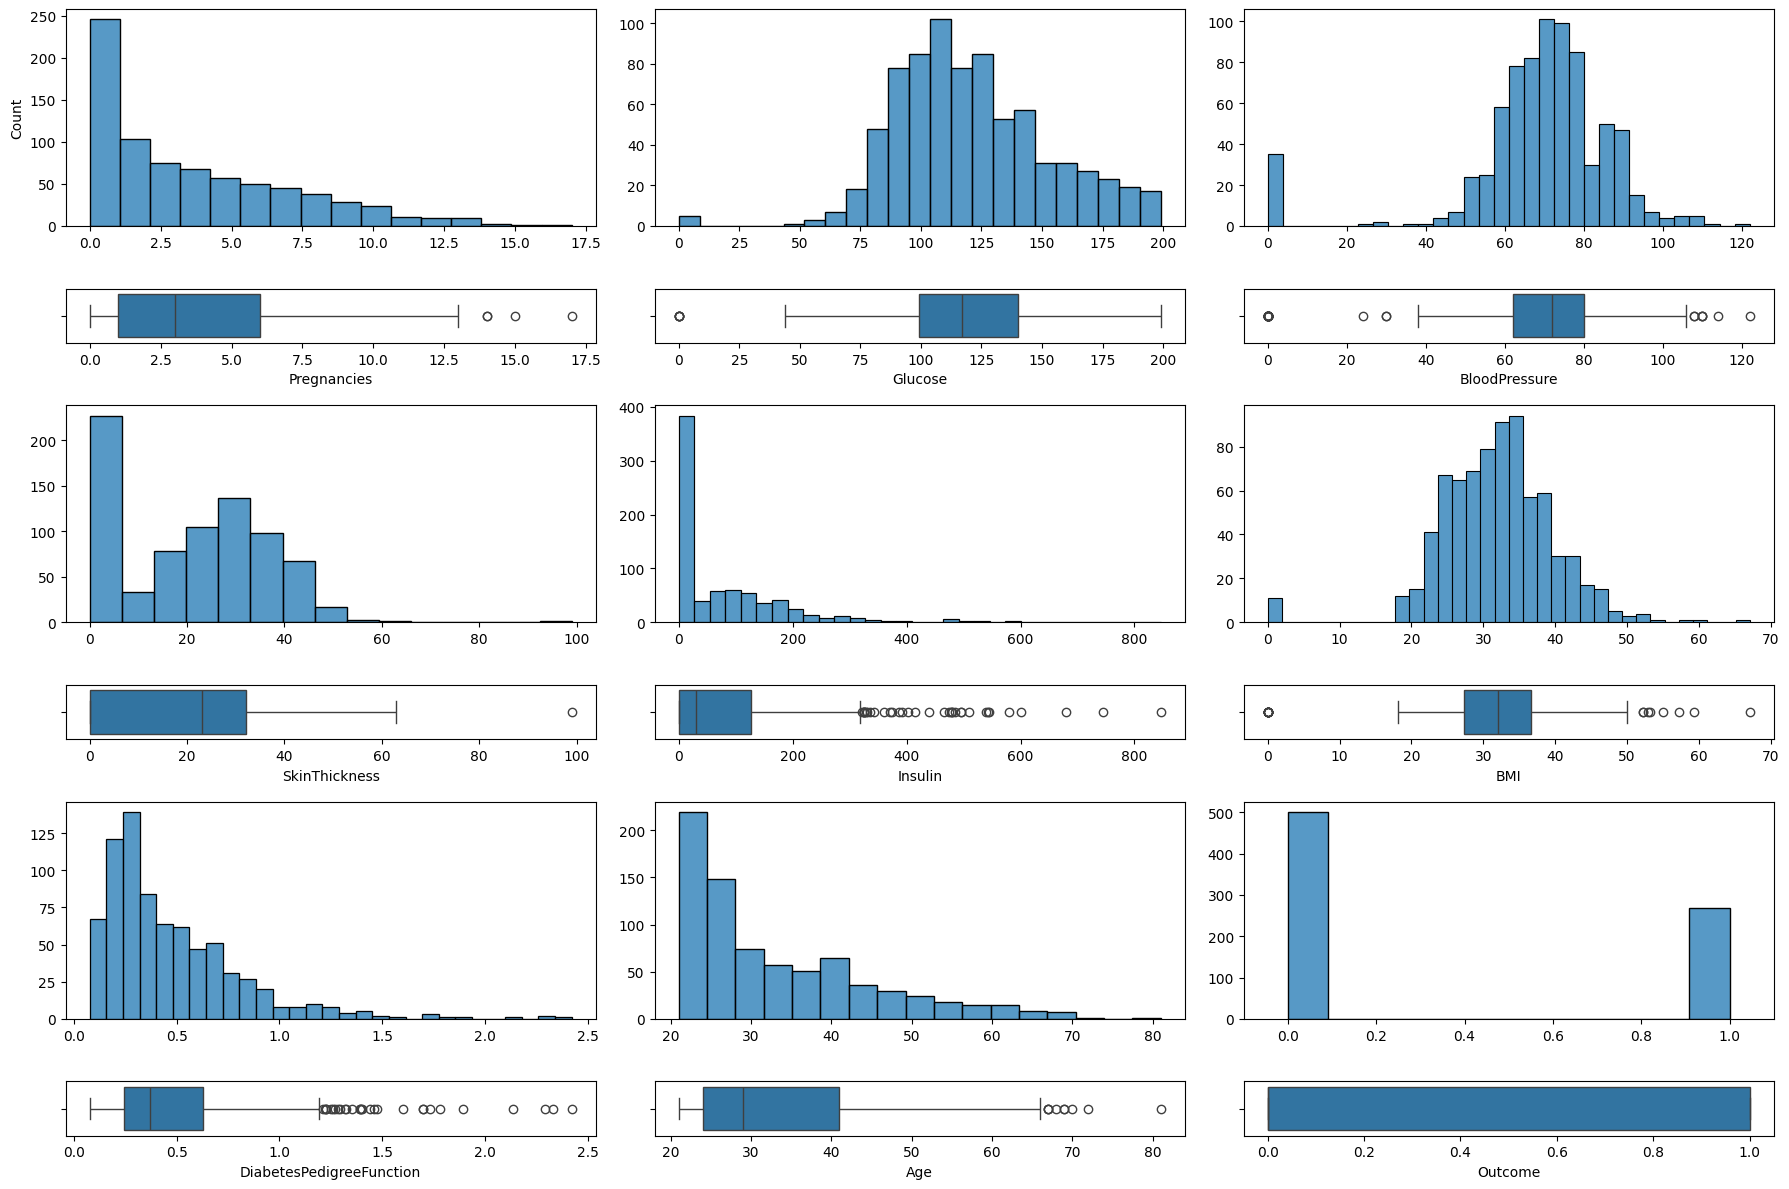

In [6]:
fig, axis = plt.subplots(6, 3, figsize = (18, 12), gridspec_kw={'height_ratios': [4, 1, 4, 1, 4, 1]})

# Crear una figura múltiple con histogramas y diagramas de caja
sns.histplot(ax = axis[0, 0], data = total_dataf, x = "Pregnancies").set(xlabel = None)
sns.boxplot(ax = axis[1, 0], data = total_dataf, x = "Pregnancies")

sns.histplot(ax = axis[0, 1], data = total_dataf, x = "Glucose").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[1, 1], data = total_dataf, x = "Glucose")

sns.histplot(ax = axis[0, 2], data = total_dataf, x = "BloodPressure").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[1, 2], data = total_dataf, x = "BloodPressure")



sns.histplot(ax = axis[2, 0], data = total_dataf, x = "SkinThickness").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[3, 0], data = total_dataf, x = "SkinThickness")

sns.histplot(ax = axis[2, 1], data = total_dataf, x = "Insulin").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[3, 1], data = total_dataf, x = "Insulin")

sns.histplot(ax = axis[2, 2], data = total_dataf, x = "BMI").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[3, 2], data = total_dataf, x = "BMI")



sns.histplot(ax = axis[4, 0], data = total_dataf, x = "DiabetesPedigreeFunction").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[5, 0], data = total_dataf, x = "DiabetesPedigreeFunction")

sns.histplot(ax = axis[4, 1], data = total_dataf, x = "Age").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[5, 1], data = total_dataf, x = "Age")

sns.histplot(ax = axis[4, 2], data = total_dataf, x = "Outcome").set(xlabel = None, ylabel = None)
axis[4,2].set_xlim(-0.1, 1.1)
sns.boxplot(ax = axis[5, 2], data = total_dataf, x = "Outcome")


# Ajustar el layout
plt.tight_layout()

# Mostrar el plot
plt.show()

## Análisis de variables multivariante

### Análisis numérico-numérico

Tomaremos el dato "Outcome" como variable objetivo

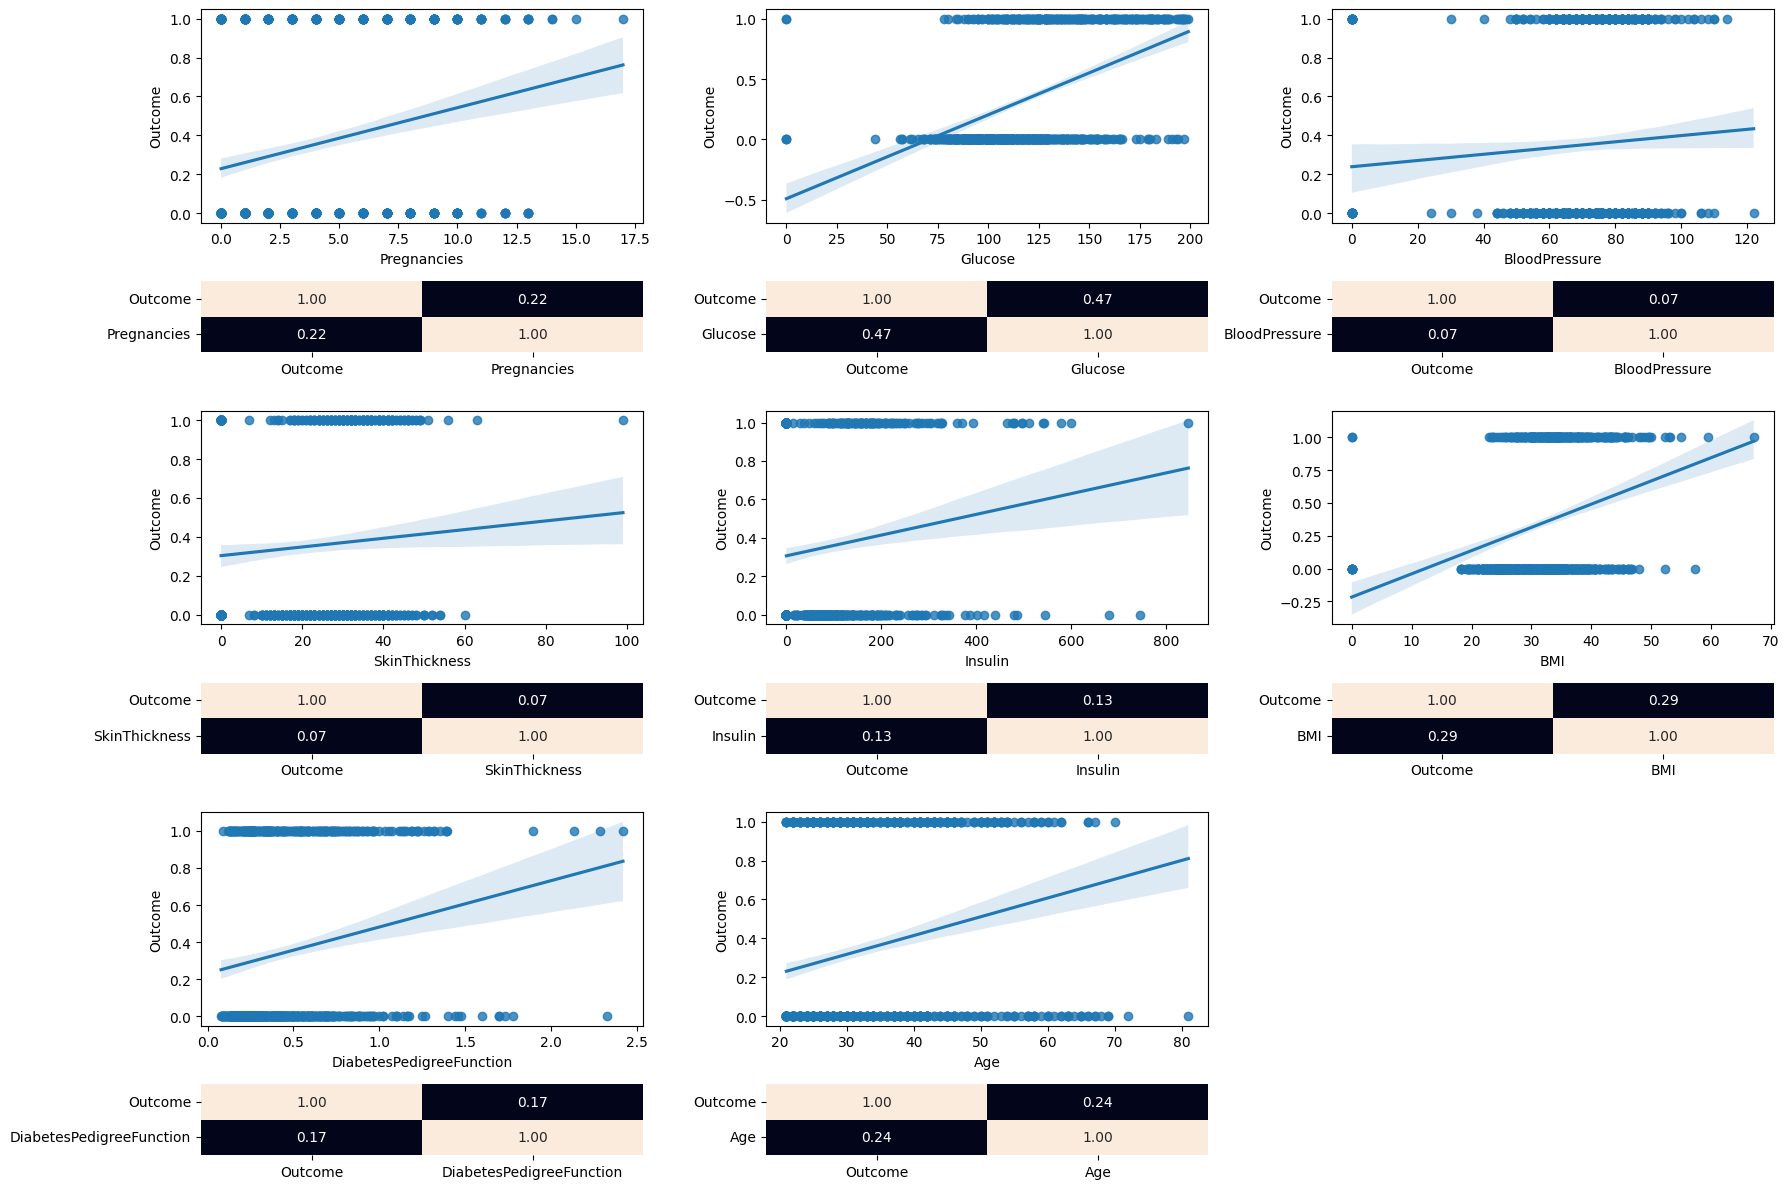

In [7]:
fig, axis = plt.subplots(6, 3, figsize = (18, 12), gridspec_kw={'height_ratios': [3, 1, 3, 1, 3, 1]})

# Crear un diagrama de dispersión múltiple
sns.regplot(ax = axis[0, 0], data = total_dataf, x = "Pregnancies", y = "Outcome")
sns.heatmap(total_dataf[["Outcome", "Pregnancies"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 0], cbar = False)

sns.regplot(ax = axis[0, 1], data = total_dataf, x = "Glucose", y = "Outcome")
sns.heatmap(total_dataf[["Outcome", "Glucose"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 1], cbar = False)

sns.regplot(ax = axis[0, 2], data = total_dataf, x = "BloodPressure", y = "Outcome")
sns.heatmap(total_dataf[["Outcome", "BloodPressure"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 2], cbar = False)

sns.regplot(ax = axis[2, 0], data = total_dataf, x = "SkinThickness", y = "Outcome")
sns.heatmap(total_dataf[["Outcome", "SkinThickness"]].corr(), annot = True, fmt = ".2f", ax = axis[3, 0], cbar = False)

sns.regplot(ax = axis[2, 1], data = total_dataf, x = "Insulin", y = "Outcome")
sns.heatmap(total_dataf[["Outcome", "Insulin"]].corr(), annot = True, fmt = ".2f", ax = axis[3, 1], cbar = False)

sns.regplot(ax = axis[2, 2], data = total_dataf, x = "BMI", y = "Outcome")
sns.heatmap(total_dataf[["Outcome", "BMI"]].corr(), annot = True, fmt = ".2f", ax = axis[3, 2], cbar = False)

sns.regplot(ax = axis[4, 0], data = total_dataf, x = "DiabetesPedigreeFunction", y = "Outcome")
sns.heatmap(total_dataf[["Outcome", "DiabetesPedigreeFunction"]].corr(), annot = True, fmt = ".2f", ax = axis[5, 0], cbar = False)

sns.regplot(ax = axis[4, 1], data = total_dataf, x = "Age", y = "Outcome")
sns.heatmap(total_dataf[["Outcome", "Age"]].corr(), annot = True, fmt = ".2f", ax = axis[5, 1], cbar = False)

fig.delaxes(axis[4, 2])
fig.delaxes(axis[5, 2])

# Ajustar el layout
plt.tight_layout()

# Mostrar el plot
plt.show()

### Combinaciones entre variables numéricas

Vamos a explorar la relación entre: Pregnancies-Glucose, Insulin-BloodPressure, BMI-BloodPressure

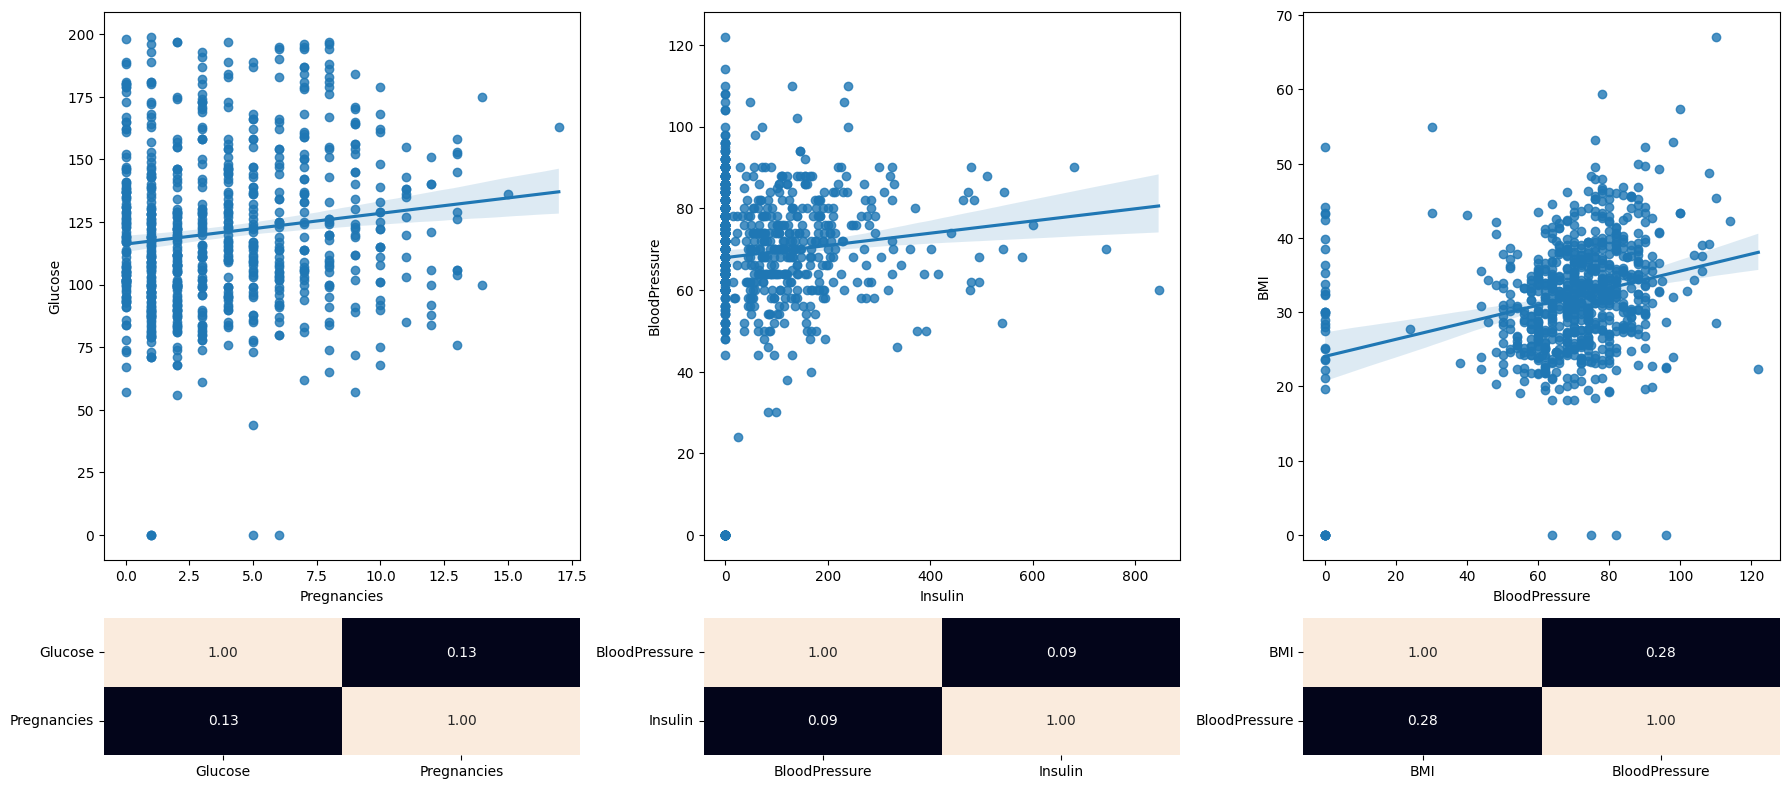

In [8]:
fig, axis = plt.subplots(2, 3, figsize = (18, 8), gridspec_kw={'height_ratios': [4, 1]})

# Crear un diagrama de dispersión múltiple
sns.regplot(ax = axis[0, 0], data = total_dataf, x = "Pregnancies", y = "Glucose")
sns.heatmap(total_dataf[["Glucose", "Pregnancies"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 0], cbar = False)

sns.regplot(ax = axis[0, 1], data = total_dataf, x = "Insulin", y = "BloodPressure")
sns.heatmap(total_dataf[["BloodPressure", "Insulin"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 1], cbar = False)

sns.regplot(ax = axis[0, 2], data = total_dataf, x = "BloodPressure", y = "BMI")
sns.heatmap(total_dataf[["BMI", "BloodPressure"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 2], cbar = False)


# Ajustar el layout
plt.tight_layout()

# Mostrar el plot
plt.show()

### Combinaciones post-mapa de calor

Podemos apreciar que existen varias relaciones que cumplen con reglas comunes como lo sería: "Age" con "Pregnancies" 0.54 donde a mayor edad, mas probable es que la paciente haya estado embarazada;
glucose con insulin 0.33 ya que cuando sube la glucosa el cuerpo intenta regularla produciendo más insulina; "SkinThickness" 0.39 con "BMI" ya que cuanta más bmi indica mayor peso en base a la altura y, por tanto,
hay un exceso de grasa que también se traduce en mayor grosor de pliegue cutáneo; "SkinThickness" con "Insulin" 0.44 porque el grosor de pliegue cutáneo indica que hay una ingesta de alimentos mayor a la requerida
por el cuerpo y el mismo tiene que regular la glucosa que entre en el subiendo los niveles de insulina

### Análisis categórico-categórico

No se puede realizar análisis dado que no hay variables categóricas.

## Análisis de correlaciones (completo)

#### Mapa de calor

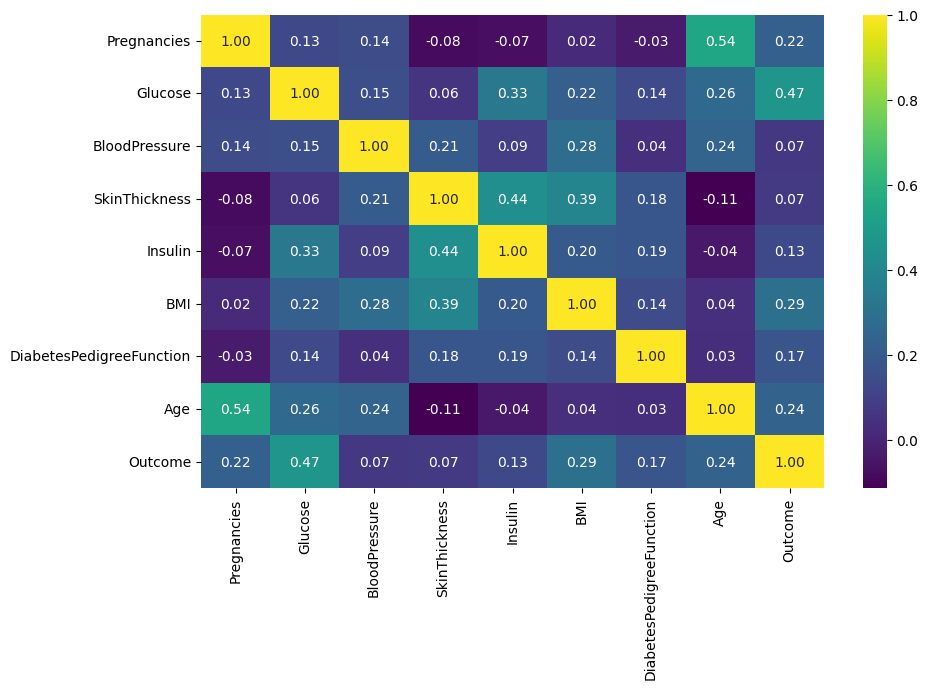

In [9]:
cols_num = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin",
       "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"]
fig, ax = plt.subplots(figsize=(10,7))
sns.heatmap(total_dataf[cols_num].corr(method="pearson"), annot=True, fmt=".2f", cmap="viridis", ax=ax)
plt.tight_layout()
plt.show()

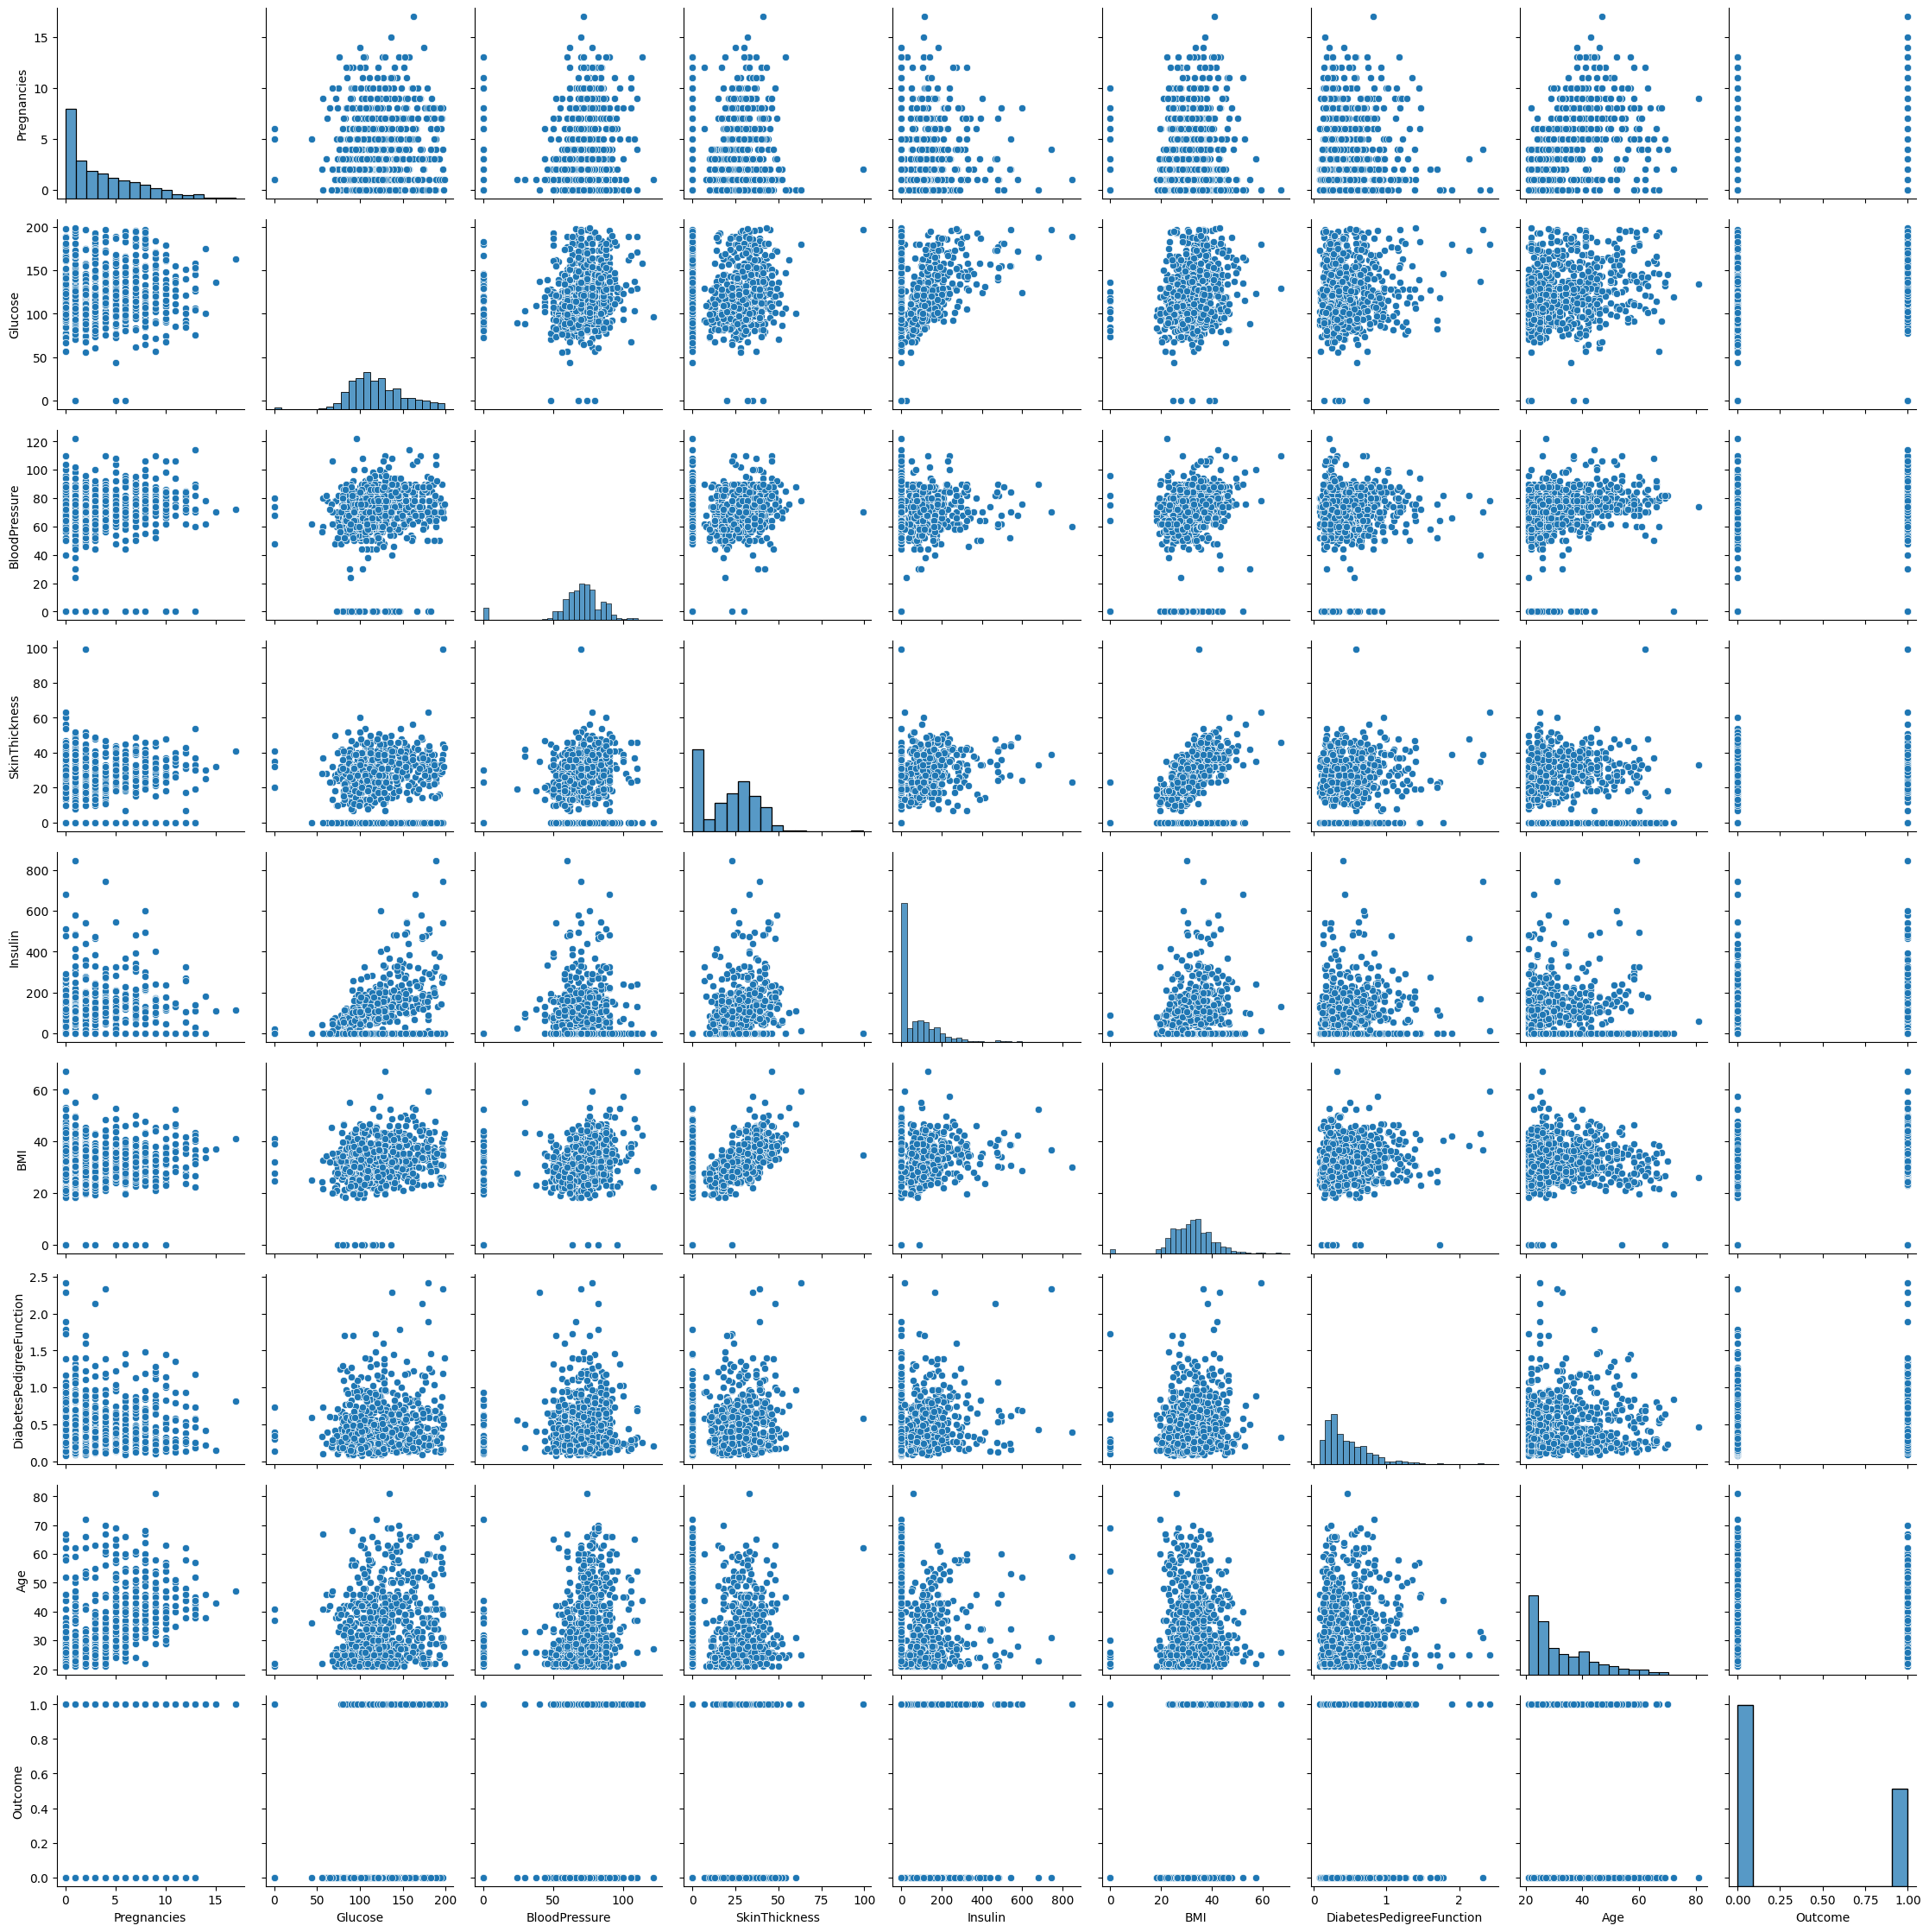

In [10]:
sns.pairplot(data = total_dataf)
plt.tight_layout()
plt.show()

## Feature engineering

### Análisis de outliers

In [11]:
FINAL_COLS = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin",
       "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"]
total_dataf = total_dataf[FINAL_COLS]
total_dataf.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [13]:
# Guardamos todos los datasets:

total_data_CON_outliers = total_dataf.copy()
total_data_SIN_outliers = total_dataf.copy()

outliers_cols = ["Pregnancies", "SkinThickness", "Insulin", "BMI"]

def replace_outliers(column, df):
  col_stats = total_dataf[column].describe()
  col_iqr = col_stats["75%"] - col_stats["25%"]
  upper_limit = round(float(col_stats["75%"] + 1.5 * col_iqr), 2)
  lower_limit = round(float(col_stats["25%"] - 1.5 * col_iqr), 2)

  if lower_limit < 0: lower_limit = min(df[column])
  # Vamos a quitar los outliers superiores
  df[column] = df[column].apply(lambda x: x if (x <= upper_limit) else upper_limit)
  # Vamos a quitar los outliers inferiores
  df[column] = df[column].apply(lambda x: x if (x >= lower_limit) else lower_limit)
  return df.copy(), [lower_limit, upper_limit]

outliers_dict = {}
for column in outliers_cols:
  total_data_SIN_outliers, limits = replace_outliers(column, total_data_SIN_outliers)
  outliers_dict.update({column: limits})

with open("../data/processed/outliers_dict.json", "w") as f:
  json.dump(outliers_dict, f)

### Análisis de valores faltantes

In [14]:
print(total_data_CON_outliers.isnull().sum().sort_values(ascending=False))
total_data_SIN_outliers.isnull().sum().sort_values(ascending=False)

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

No hay valores nulos

### Inferencia de nuevas características

### Escalado de valores

In [15]:
predictoras = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin",
       "BMI", "DiabetesPedigreeFunction", "Age"]
target = "Outcome"

X_CON = total_data_CON_outliers.drop(target, axis = 1)[predictoras]
X_SIN = total_data_SIN_outliers.drop(target, axis = 1)[predictoras]
y = total_data_CON_outliers[target]

X_train_CON_outliers, X_test_CON_outliers, y_train, y_test = train_test_split(X_CON, y, test_size = 0.2, random_state = 10)
X_train_SIN_outliers, X_test_SIN_outliers = train_test_split(X_SIN, test_size = 0.2, random_state = 10)

In [16]:
# Normalización

norm_CON_outliers = StandardScaler()

norm_CON_outliers.fit(X_train_CON_outliers)

X_train_CON_outliers_norm = norm_CON_outliers.transform(X_train_CON_outliers)
X_train_CON_outliers_norm = pd.DataFrame(X_train_CON_outliers_norm, index = X_train_CON_outliers.index, columns = predictoras)

X_test_CON_outliers_norm = norm_CON_outliers.transform(X_test_CON_outliers)
X_test_CON_outliers_norm = pd.DataFrame(X_test_CON_outliers_norm, index = X_test_CON_outliers.index, columns = predictoras)

# SIN OUTLIERS
norm_SIN_outliers = StandardScaler()
norm_SIN_outliers.fit(X_train_SIN_outliers)

X_train_SIN_outliers_norm = norm_SIN_outliers.transform(X_train_SIN_outliers)
X_train_SIN_outliers_norm = pd.DataFrame(X_train_SIN_outliers_norm, index = X_train_SIN_outliers.index, columns = predictoras)

X_test_SIN_outliers_norm = norm_SIN_outliers.transform(X_test_SIN_outliers)
X_test_SIN_outliers_norm = pd.DataFrame(X_test_SIN_outliers_norm, index = X_test_SIN_outliers.index, columns = predictoras)


# ESCALADO MIN-MAX (MINMAXIMIZACIÓN)

scaler_CON_outliers = MinMaxScaler()
scaler_CON_outliers.fit(X_train_CON_outliers)

X_train_CON_outliers_scal = scaler_CON_outliers.transform(X_train_CON_outliers)
X_train_CON_outliers_scal = pd.DataFrame(X_train_CON_outliers_scal, index = X_train_CON_outliers.index, columns = predictoras)

X_test_CON_outliers_scal = scaler_CON_outliers.transform(X_test_CON_outliers)
X_test_CON_outliers_scal = pd.DataFrame(X_test_CON_outliers_scal, index = X_test_CON_outliers.index, columns = predictoras)

# SIN OUTLIERS
scaler_SIN_outliers = MinMaxScaler()
scaler_SIN_outliers.fit(X_train_SIN_outliers)

X_train_SIN_outliers_scal = scaler_SIN_outliers.transform(X_train_SIN_outliers)
X_train_SIN_outliers_scal = pd.DataFrame(X_train_SIN_outliers_scal, index = X_train_SIN_outliers.index, columns = predictoras)

X_test_SIN_outliers_scal = scaler_SIN_outliers.transform(X_test_SIN_outliers)
X_test_SIN_outliers_scal = pd.DataFrame(X_test_SIN_outliers_scal, index = X_test_SIN_outliers.index, columns = predictoras)


# Guardado de los datasets resultantes
X_train_CON_outliers.to_excel("../data/processed/X_train_CON_outliers.xlsx", index = False)
X_train_CON_outliers_norm.to_excel("../data/processed/X_train_CON_outliers_norm.xlsx", index = False)
X_train_CON_outliers_scal.to_excel("../data/processed/X_train_CON_outliers_scal.xlsx", index = False)
X_train_SIN_outliers.to_excel("../data/processed/X_train_SIN_outliers.xlsx", index = False)
X_train_SIN_outliers_norm.to_excel("../data/processed/X_train_SIN_outliers_norm.xlsx", index = False)
X_train_SIN_outliers_scal.to_excel("../data/processed/X_train_SIN_outliers_scal.xlsx", index = False)

X_test_CON_outliers.to_excel("../data/processed/X_test_CON_outliers.xlsx", index = False)
X_test_CON_outliers_norm.to_excel("../data/processed/X_test_CON_outliers_norm.xlsx", index = False)
X_test_CON_outliers_scal.to_excel("../data/processed/X_test_CON_outliers_scal.xlsx", index = False)
X_test_SIN_outliers.to_excel("../data/processed/X_test_SIN_outliers.xlsx", index = False)
X_test_SIN_outliers_norm.to_excel("../data/processed/X_test_SIN_outliers_norm.xlsx", index = False)
X_test_SIN_outliers_scal.to_excel("../data/processed/X_test_SIN_outliers_scal.xlsx", index = False)

y_train.to_excel("../data/processed/y_train.xlsx", index = False)
y_test.to_excel("../data/processed/y_test.xlsx", index = False)

# SCALERS

with open("../models/norm_CON_outliers.pkl", "wb") as file:
  pickle.dump(norm_CON_outliers, file)
with open("../models/norm_SIN_outliers.pkl", "wb") as file:
  pickle.dump(norm_SIN_outliers, file)
with open("../models/scaler_CON_outliers.pkl", "wb") as file:
  pickle.dump(scaler_CON_outliers, file)
with open("../models/scaler_SIN_outliers.pkl", "wb") as file:
  pickle.dump(scaler_SIN_outliers, file)

## Feature Selection

In [17]:
X_train = X_train_CON_outliers.copy()
X_test = X_test_CON_outliers.copy()

selection_model = SelectKBest(f_classif, k = 5)
selection_model.fit(X_train, y_train)

ix = selection_model.get_support()
X_train_sel = pd.DataFrame(selection_model.transform(X_train), columns = X_train.columns.values[ix])
X_test_sel = pd.DataFrame(selection_model.transform(X_test), columns = X_test.columns.values[ix])

X_train_sel.head()

,Pregnancies,Glucose,BMI,DiabetesPedigreeFunction,Age
0,0.0,162.0,53.2,0.759,25.0
1,2.0,87.0,28.9,0.773,25.0
2,0.0,137.0,24.8,0.143,21.0
3,10.0,115.0,35.3,0.134,29.0
4,0.0,104.0,33.6,0.510,22.0
